# Pro Stuff+

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pybaseball
pybaseball.cache.enable()

## Import Data

In [17]:
from pybaseball import statcast

# get all available data
df = statcast('2022-04-07', '2024-07-31')

TypeError: Cannot convert numpy.ndarray to numpy.ndarray

## Preprocess Data

In [9]:
df.columns.to_list()

['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

In [10]:
df['description'].unique()

array(['hit_into_play', 'ball', 'automatic_ball', 'foul_tip',
       'blocked_ball', 'swinging_strike', 'foul', 'called_strike',
       'foul_bunt', 'swinging_strike_blocked', 'hit_by_pitch',
       'missed_bunt', 'automatic_strike', 'pitchout', 'bunt_foul_tip'],
      dtype=object)

In [11]:
stuffCols = ['release_speed', 'release_pos_x', 'release_pos_z',
             'pfx_x', 'pfx_z', 'spin_axis',
             'release_spin_rate', 'release_extension']

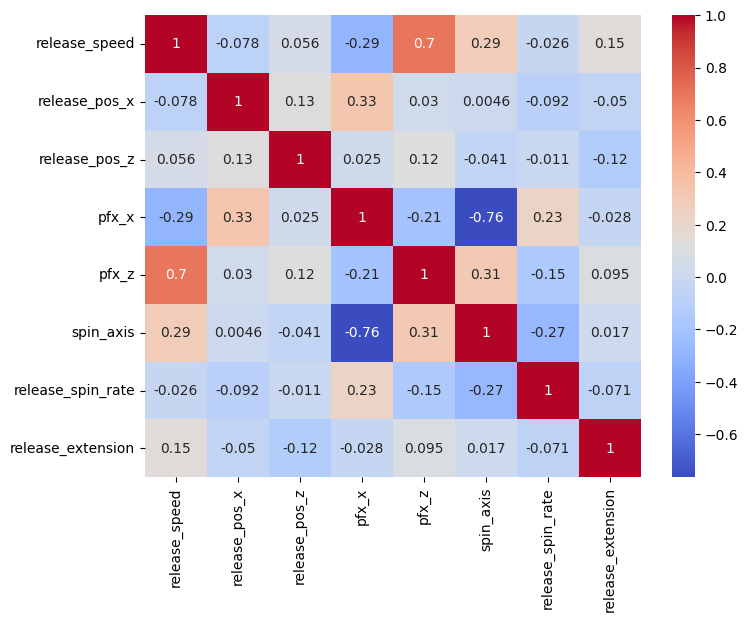

In [12]:
# Show correlation matrix
corr = df[stuffCols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## xwOBA

### Baseline xwOBA Predictor

In [6]:
# Baseline: predict estimated_woba_using_speedangle from stuffCols (MAE, RMSE, R2, AdjR2)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np, pandas as pd

target = 'estimated_woba_using_speedangle'
if target not in df.columns:
    raise RuntimeError(f"Target '{target}' not found in df")

# build feature + target table, coerce to numeric, then drop rows with any NA to keep X and y aligned
use_cols = list(stuffCols) + [target]
data = df[use_cols].copy()
X = data[stuffCols].apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(data[target], errors='coerce')
combined = pd.concat([X, y], axis=1).dropna()
X = combined[stuffCols]
y = combined[target].astype(float)

print(f'Using {len(X)} rows and {len(X.columns)} features')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Try CatBoost if installed, otherwise RandomForest fallback
try:
    from catboost import CatBoostRegressor
    model = CatBoostRegressor(iterations=500, learning_rate=0.1,
                              eval_metric='RMSE', random_seed=42,
                              early_stopping_rounds=30, verbose=0)
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    preds = model.predict(X_val)
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

mae = mean_absolute_error(y_val, preds)
rmse = root_mean_squared_error(y_val, preds)
r2 = r2_score(y_val, preds)
n = len(y_val)
p = X_val.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if (n - p - 1) > 0 else float('nan')

print(f'Validation MAE: {mae:.5f}')
print(f'Validation RMSE: {rmse:.5f}')
print(f'R^2: {r2:.5f}')
print(f'Adjusted R^2: {adj_r2:.5f}')

Using 488168 rows and 8 features
Validation MAE: 0.29675
Validation RMSE: 0.36532
R^2: 0.01719
Adjusted R^2: 0.01711


### Feature Engineered xwOBA Predictor

In [7]:
# Feature builder (repeatable, no high-cardinality one-hot) for xwOBA modeling
import os, json
import numpy as np
import pandas as pd

mappings_dir = 'mappings'
os.makedirs(mappings_dir, exist_ok=True)

# Ensure base columns exist
base_cols = list(stuffCols)  # uses stuffCols already defined in the notebook
extra_possible = ['px', 'pz','release_speed', 'pfx_x', 'pfx_z',
                  'spin_axis', 'release_pos_x', 'release_pos_z', 'release_extension']
use_cols = [c for c in base_cols + extra_possible if c in df.columns]

# Work copy
work = df[use_cols].copy()

# ensure no duplicate column labels (keeps first occurrence)
work = work.loc[:, ~work.columns.duplicated()]

# Convert obvious numerics (guard if an index returns a DataFrame)
for c in work.columns:
    col = work[c]
    if isinstance(col, pd.DataFrame):
        # collapse to first column if duplicate labels produced a DataFrame
        col = col.iloc[:, 0]
        work[c] = col
    if col.dtype == 'object':
        continue
    work[c] = pd.to_numeric(col, errors='coerce')

# Derived features: speed transforms
if 'release_speed' in work.columns:
    work['release_speed_sq'] = work['release_speed'] ** 2
    work['log_release_speed'] = np.log1p(work['release_speed'])

# Derived: pitch movement magnitude
if 'pfx_x' in work.columns or 'pfx_z' in work.columns:
    px_val = work.get('pfx_x', pd.Series(0, index=work.index)).fillna(0)
    pz_val = work.get('pfx_z', pd.Series(0, index=work.index)).fillna(0)
    work['pfx_magnitude'] = np.sqrt(px_val**2 + pz_val**2)

# Spin axis -> sin/cos components
if 'spin_axis' in work.columns:
    work['spin_axis_rad'] = np.deg2rad(work['spin_axis'].astype(float))
    work['spin_cos'] = np.cos(work['spin_axis_rad'])
    work['spin_sin'] = np.sin(work['spin_axis_rad'])

# Release position interactions
if 'release_pos_x' in work.columns and 'release_pos_z' in work.columns:
    work['release_side'] = work['release_pos_x']
    work['release_height'] = work['release_pos_z']
    work['release_side_times_height'] = work['release_pos_x'] * work['release_pos_z']

# Location proxy: distance to zone center (use median pz if available)
pz_center = work['pz'].median() if 'pz' in work.columns and work['pz'].notna().any() else 2.5
px_center = 0.0
if 'pz' in work.columns:
    work['dist_zone_center'] = np.sqrt(work.get('px', 0)**2 + (work['pz'] - pz_center)**2)

# Label-encode small categorical(s) (persist mapping)
if 'pitch_type' in work.columns:
    codes, uniques = pd.factorize(work['pitch_type'].astype(str))
    work['pitch_type_code'] = codes
    pitch_map = {str(v): int(i) for i, v in enumerate(uniques)}
    with open(os.path.join(mappings_dir, 'pitch_type_map.json'), 'w') as f:
        json.dump(pitch_map, f)

# Drop high-cardinality identifiers to avoid one-hot / leakage
for col in ['pitcher', 'batter_id', 'umpire_id', 'catcher_id']:
    if col in work.columns:
        work.drop(columns=[col], inplace=True, errors='ignore')

# Final feature list (numeric only)
feat_cols = [c for c in work.columns if pd.api.types.is_numeric_dtype(work[c])]

# Impute numeric missing with median and add missing indicator for large gaps
for c in feat_cols:
    if work[c].isna().any():
        med = work[c].median()
        work[c + '_missing'] = work[c].isna().astype(int)
        work[c] = work[c].fillna(med)

# Align with target and produce feature DataFrame X (ready for modeling)
target = 'estimated_woba_using_speedangle'
if target not in df.columns:
    raise RuntimeError(f"Target '{target}' not found in df")
y = pd.to_numeric(df[target], errors='coerce')
X = work[feat_cols].copy()
combined = pd.concat([X, y], axis=1).dropna()
X = combined[feat_cols]
y = combined[target].astype(float)

# Persist feature list for reproducibility
with open(os.path.join(mappings_dir, 'feature_list.json'), 'w') as f:
    json.dump({'features': feat_cols}, f)

print(f'Built features: {len(feat_cols)} numeric columns; final rows={len(X)}')
# X and y are ready to be used for training your xwOBA model

Built features: 17 numeric columns; final rows=490855


In [8]:
# Train xwOBA using engineered features + show ALL feature importances
import os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Use existing X/y from previous cell if available, otherwise try to reconstruct from mapping
if 'X' not in globals() or 'y' not in globals():
    mapping_path = os.path.join('mappings', 'feature_list.json')
    if os.path.exists(mapping_path):
        with open(mapping_path, 'r') as f:
            feat_meta = json.load(f)
        feat_cols = feat_meta.get('features', [])
        if not feat_cols:
            raise RuntimeError('feature_list.json exists but contains no features')
        X = df[feat_cols].copy()
        X = X.loc[:, ~X.columns.duplicated()]
        for c in X.columns:
            X[c] = pd.to_numeric(X[c], errors='coerce')
        for c in X.columns:
            if X[c].isna().any():
                X[c] = X[c].fillna(X[c].median())
        target = 'estimated_woba_using_speedangle'
        if target not in df.columns:
            raise RuntimeError(f"Target '{target}' not found in df")
        y = pd.to_numeric(df[target], errors='coerce')
        combined = pd.concat([X, y], axis=1).dropna()
        X = combined[X.columns]
        y = combined[target].astype(float)
    else:
        raise RuntimeError("X and y not in memory and no mappings/feature_list.json found. Run the feature builder cell first.")

print(f'Features: {X.shape[1]}, Rows: {len(X)}')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train CatBoost if available, else RandomForest
try:
    from catboost import CatBoostRegressor
    model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.05,
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    preds = model.predict(X_val)
    try:
        fi = model.get_feature_importance()
        fi_df = pd.DataFrame({'feature': X.columns, 'importance': fi}).sort_values('importance', ascending=False)
        print('\nAll features (CatBoost importance):')
        print(fi_df.to_string(index=False))
    except Exception:
        pass
except Exception as e:
    print('CatBoost unavailable or failed:', e)
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    fi_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
    print('\nAll features (RF importance):')
    print(fi_df.to_string(index=False))

mae = mean_absolute_error(y_val, preds)
rmse = root_mean_squared_error(y_val, preds)
r2 = r2_score(y_val, preds)
n = len(y_val)
p = X_val.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if (n - p - 1) > 0 else float('nan')

print('\nResults:')
print(f'Validation MAE: {mae:.5f}')
print(f'Validation RMSE: {rmse:.5f}')
print(f'R^2: {r2:.5f}')
print(f'Adjusted R^2: {adj_r2:.5f}')

Features: 17, Rows: 490855
0:	learn: 0.3683178	test: 0.3671265	best: 0.3671265 (0)	total: 10.1ms	remaining: 8.05s
100:	learn: 0.3657099	test: 0.3647234	best: 0.3647234 (100)	total: 906ms	remaining: 6.27s
200:	learn: 0.3652239	test: 0.3644374	best: 0.3644374 (200)	total: 1.78s	remaining: 5.32s
300:	learn: 0.3648004	test: 0.3642693	best: 0.3642693 (300)	total: 2.66s	remaining: 4.41s
400:	learn: 0.3643768	test: 0.3642022	best: 0.3642022 (400)	total: 3.53s	remaining: 3.52s
500:	learn: 0.3640350	test: 0.3641674	best: 0.3641674 (500)	total: 4.4s	remaining: 2.62s
600:	learn: 0.3637035	test: 0.3641422	best: 0.3641409 (590)	total: 5.28s	remaining: 1.75s
700:	learn: 0.3633979	test: 0.3641198	best: 0.3641168 (688)	total: 6.15s	remaining: 868ms
799:	learn: 0.3630996	test: 0.3641024	best: 0.3641019 (783)	total: 7.02s	remaining: 0us

bestTest = 0.3641019111
bestIteration = 783

Shrink model to first 784 iterations.

All features (CatBoost importance):
                  feature  importance
          

### Save xwOBA Predictor

In [9]:
# Save xwOBA model for later use
import joblib
import json
import os

# Create models directory if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the trained model
model_type = type(model).__name__
if 'CatBoost' in model_type:
    model_path = os.path.join(models_dir, 'xwoba_model.cbm')
    model.save_model(model_path)
    print(f'CatBoost model saved to {model_path}')
else:
    model_path = os.path.join(models_dir, 'xwoba_model.pkl')
    joblib.dump(model, model_path)
    print(f'RandomForest model saved to {model_path}')

# Save model metadata (features, metrics, feature importance)
metadata = {
    'model_type': model_type,
    'features': list(X.columns),
    'n_features': X.shape[1],
    'n_train_samples': len(X_train),
    'n_val_samples': len(X_val),
    'metrics': {
        'mae': float(mae),
        'rmse': float(rmse),
        'r2': float(r2),
        'adj_r2': float(adj_r2)
    },
    'feature_importance': fi_df.to_dict('records') if 'fi_df' in locals() else []
}

metadata_path = os.path.join(models_dir, 'xwoba_model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Model metadata saved to {metadata_path}')

print(f'\nModel and metadata saved. To load later:\n'
      f'  from catboost import CatBoostRegressor\n'
      f'  model = CatBoostRegressor().load_model("{model_path}")\n'
      f'  (or use joblib.load for RandomForest)')

CatBoost model saved to models/xwoba_model.cbm
Model metadata saved to models/xwoba_model_metadata.json

Model and metadata saved. To load later:
  from catboost import CatBoostRegressor
  model = CatBoostRegressor().load_model("models/xwoba_model.cbm")
  (or use joblib.load for RandomForest)


## In-Zone Miss

In [18]:
# Build miss binary classifier WITH class weight balancing
import os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, brier_score_loss, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Define miss based on actual description values
df['miss'] = df['description'].isin(['swinging_strike', 'swinging_strike_blocked', 'missed_bunt']).astype(int)

print(f'Total pitches: {len(df)}')
print(f'Misses: {df["miss"].sum()}')
miss_rate = df["miss"].sum() / len(df)
print(f'Miss rate: {miss_rate * 100:.2f}%')
print(f'Class ratio (no-miss:miss): {(1-miss_rate)/miss_rate:.2f}:1')

# [Feature engineering code stays the same - abbreviated here]
base_cols = list(stuffCols)
extra_possible = ['px', 'pz', 'release_speed', 'pfx_x', 'pfx_z',
                  'spin_axis', 'release_pos_x', 'release_pos_z', 'release_extension']
use_cols = [c for c in base_cols + extra_possible if c in df.columns]

work = df[use_cols].copy()
work = work.loc[:, ~work.columns.duplicated()]

for c in work.columns:
    col = work[c]
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]
        work[c] = col
    if col.dtype != 'object':
        work[c] = pd.to_numeric(col, errors='coerce')

if 'release_speed' in work.columns:
    work['release_speed_sq'] = work['release_speed'] ** 2
    work['log_release_speed'] = np.log1p(work['release_speed'])

if 'pfx_x' in work.columns or 'pfx_z' in work.columns:
    px_val = work.get('pfx_x', pd.Series(0, index=work.index)).fillna(0)
    pz_val = work.get('pfx_z', pd.Series(0, index=work.index)).fillna(0)
    work['pfx_magnitude'] = np.sqrt(px_val**2 + pz_val**2)

if 'spin_axis' in work.columns:
    work['spin_axis_rad'] = np.deg2rad(work['spin_axis'].astype(float))
    work['spin_cos'] = np.cos(work['spin_axis_rad'])
    work['spin_sin'] = np.sin(work['spin_axis_rad'])

if 'release_pos_x' in work.columns and 'release_pos_z' in work.columns:
    work['release_side'] = work['release_pos_x']
    work['release_height'] = work['release_pos_z']
    work['release_side_times_height'] = work['release_pos_x'] * work['release_pos_z']

pz_center = work['pz'].median() if 'pz' in work.columns and work['pz'].notna().any() else 2.5
if 'pz' in work.columns:
    work['dist_zone_center'] = np.sqrt(work.get('px', 0)**2 + (work['pz'] - pz_center)**2)

if 'pitch_type' in work.columns:
    codes, uniques = pd.factorize(work['pitch_type'].astype(str))
    work['pitch_type_code'] = codes

for col in ['pitcher', 'batter_id', 'umpire_id', 'catcher_id']:
    if col in work.columns:
        work.drop(columns=[col], inplace=True, errors='ignore')

feat_cols = [c for c in work.columns if pd.api.types.is_numeric_dtype(work[c])]

for c in feat_cols:
    if work[c].isna().any():
        med = work[c].median()
        work[c + '_missing'] = work[c].isna().astype(int)
        work[c] = work[c].fillna(med)

X = work[feat_cols].copy()
y = df['miss'].astype(int)
combined = pd.concat([X, y], axis=1).dropna()
X = combined[feat_cols]
y = combined['miss'].astype(int)

print(f'\nFeatures: {X.shape[1]}, Rows: {len(X)}, Positives: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train classifier WITH CLASS WEIGHT BALANCING
try:
    from catboost import CatBoostClassifier
    # Calculate scale_pos_weight to balance classes
    scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
    
    model = CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        eval_metric='AUC',
        random_seed=42,
        early_stopping_rounds=50,
        scale_pos_weight=scale_pos_weight,  # KEY: Weight positive class
        verbose=100
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    preds = model.predict(X_val)
    preds_proba = model.predict_proba(X_val)[:, 1]
    try:
        fi = model.get_feature_importance()
        fi_df = pd.DataFrame({'feature': X.columns, 'importance': fi}).sort_values('importance', ascending=False)
        print('\nTop 20 features (miss):')
        print(fi_df.head(20).to_string(index=False))
    except Exception:
        pass
except Exception as e:
    print('CatBoost unavailable:', e)
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, max_depth=15, class_weight='balanced')
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    preds_proba = model.predict_proba(X_val)[:, 1]
    fi_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
    print('\nTop 20 features (miss):')
    print(fi_df.head(20).to_string(index=False))

# Classification metrics
auc = roc_auc_score(y_val, preds_proba)
precision = precision_score(y_val, preds, zero_division=0)
recall = recall_score(y_val, preds, zero_division=0)
f1 = f1_score(y_val, preds, zero_division=0)
brier = brier_score_loss(y_val, preds_proba)
tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f'\nResults (miss classifier with class weight balancing):')
print(f'AUC: {auc:.5f}')
print(f'Precision: {precision:.5f}')
print(f'Recall (Sensitivity): {recall:.5f}')
print(f'Specificity: {specificity:.5f}')
print(f'F1 Score: {f1:.5f}')
print(f'Brier Score: {brier:.5f}')
print(f'Confusion Matrix:\n  True Negatives: {tn}, False Positives: {fp}\n  False Negatives: {fn}, True Positives: {tp}')

Total pitches: 2008693
Misses: 228107
Miss rate: 11.36%
Class ratio (no-miss:miss): 7.81:1

Features: 17, Rows: 2008693, Positives: 228107 (11.4%)
0:	test: 0.5896964	best: 0.5896964 (0)	total: 77.8ms	remaining: 1m 2s
100:	test: 0.6146678	best: 0.6146678 (100)	total: 7.79s	remaining: 53.9s
200:	test: 0.6186182	best: 0.6186182 (200)	total: 15.4s	remaining: 45.8s
300:	test: 0.6210535	best: 0.6210535 (300)	total: 23.1s	remaining: 38.2s
400:	test: 0.6229418	best: 0.6229418 (400)	total: 30.9s	remaining: 30.7s
500:	test: 0.6241612	best: 0.6241612 (500)	total: 38.6s	remaining: 23s
600:	test: 0.6251329	best: 0.6251346 (599)	total: 46.3s	remaining: 15.3s
700:	test: 0.6258021	best: 0.6258069 (699)	total: 54s	remaining: 7.63s
799:	test: 0.6263476	best: 0.6263545 (796)	total: 1m 1s	remaining: 0us

bestTest = 0.626354467
bestIteration = 796

Shrink model to first 797 iterations.

Top 20 features (miss):
                  feature  importance
                    pfx_z   17.018163
         release_spee

In [25]:
# Save miss model for later use
import joblib
import json
import os

models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the trained model
model_type = type(model).__name__
if 'CatBoost' in model_type:
    model_path = os.path.join(models_dir, 'miss_model.cbm')
    model.save_model(model_path)
    print(f'CatBoost model saved to {model_path}')
else:
    model_path = os.path.join(models_dir, 'miss_model.pkl')
    joblib.dump(model, model_path)
    print(f'RandomForest model saved to {model_path}')

# Save model metadata
metadata = {
    'model_type': model_type,
    'features': list(X.columns),
    'n_features': X.shape[1],
    'n_train_samples': len(X_train),
    'n_val_samples': len(X_val),
    'metrics': {
        'auc': float(auc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'specificity': float(specificity),
        'brier': float(brier)
    },
    'feature_importance': fi_df.to_dict('records') if 'fi_df' in locals() else []
}

metadata_path = os.path.join(models_dir, 'miss_model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Model metadata saved to {metadata_path}')

CatBoost model saved to models/miss_model.cbm
Model metadata saved to models/miss_model_metadata.json


## Chase

In [19]:
# Build chase binary classifier (swing outside zone)
import os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, brier_score_loss, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Define strike zone boundaries
zone_x_min, zone_x_max = -8.5/12, 8.5/12
zone_z_min, zone_z_max = 1.6, 3.5

# Identify pitches in zone
in_zone = (df['plate_x'].ge(zone_x_min)) & (df['plate_x'].le(zone_x_max)) & \
          (df['plate_z'].ge(zone_z_min)) & (df['plate_z'].le(zone_z_max))
in_zone = in_zone.fillna(False)

# Identify swings (any swing-related outcome)
swing_outcomes = ['swinging_strike', 'swinging_strike_blocked', 'missed_bunt', 
                  'foul', 'foul_bunt', 'foul_tip', 'bunt_foul_tip', 'hit_into_play']
is_swing = df['description'].isin(swing_outcomes)

# Chase = swing outside the zone
df['chase'] = ((is_swing) & (~in_zone)).astype(int)

print(f'Total pitches: {len(df)}')
print(f'Total swings: {is_swing.sum()}')
print(f'Chases (swings outside zone): {df["chase"].sum()}')
chase_rate = df["chase"].sum() / is_swing.sum() if is_swing.sum() > 0 else 0
print(f'Chase rate (% of swings): {chase_rate * 100:.2f}%')
print(f'Overall chase rate: {df["chase"].sum() / len(df) * 100:.2f}%')

# Rebuild engineered features
base_cols = list(stuffCols)
extra_possible = ['px', 'pz', 'release_speed', 'pfx_x', 'pfx_z',
                  'spin_axis', 'release_pos_x', 'release_pos_z', 'release_extension']
use_cols = [c for c in base_cols + extra_possible if c in df.columns]

work = df[use_cols].copy()
work = work.loc[:, ~work.columns.duplicated()]

for c in work.columns:
    col = work[c]
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]
        work[c] = col
    if col.dtype != 'object':
        work[c] = pd.to_numeric(col, errors='coerce')

if 'release_speed' in work.columns:
    work['release_speed_sq'] = work['release_speed'] ** 2
    work['log_release_speed'] = np.log1p(work['release_speed'])

if 'pfx_x' in work.columns or 'pfx_z' in work.columns:
    px_val = work.get('pfx_x', pd.Series(0, index=work.index)).fillna(0)
    pz_val = work.get('pfx_z', pd.Series(0, index=work.index)).fillna(0)
    work['pfx_magnitude'] = np.sqrt(px_val**2 + pz_val**2)

if 'spin_axis' in work.columns:
    work['spin_axis_rad'] = np.deg2rad(work['spin_axis'].astype(float))
    work['spin_cos'] = np.cos(work['spin_axis_rad'])
    work['spin_sin'] = np.sin(work['spin_axis_rad'])

if 'release_pos_x' in work.columns and 'release_pos_z' in work.columns:
    work['release_side'] = work['release_pos_x']
    work['release_height'] = work['release_pos_z']
    work['release_side_times_height'] = work['release_pos_x'] * work['release_pos_z']

pz_center = work['pz'].median() if 'pz' in work.columns and work['pz'].notna().any() else 2.5
if 'pz' in work.columns:
    work['dist_zone_center'] = np.sqrt(work.get('px', 0)**2 + (work['pz'] - pz_center)**2)

if 'pitch_type' in work.columns:
    codes, uniques = pd.factorize(work['pitch_type'].astype(str))
    work['pitch_type_code'] = codes

for col in ['pitcher', 'batter_id', 'umpire_id', 'catcher_id']:
    if col in work.columns:
        work.drop(columns=[col], inplace=True, errors='ignore')

feat_cols = [c for c in work.columns if pd.api.types.is_numeric_dtype(work[c])]

for c in feat_cols:
    if work[c].isna().any():
        med = work[c].median()
        work[c + '_missing'] = work[c].isna().astype(int)
        work[c] = work[c].fillna(med)

# Align with target (only swings - chase is only meaningful for swings)
X = work[feat_cols].copy()
y = df['chase'].astype(int)
combined = pd.concat([X, y], axis=1).dropna()
X = combined[feat_cols]
y = combined['chase'].astype(int)

print(f'\nFeatures: {X.shape[1]}, Rows: {len(X)}, Chases: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train classifier WITH CLASS WEIGHT BALANCING
try:
    from catboost import CatBoostClassifier
    scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
    
    model = CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        eval_metric='AUC',
        random_seed=42,
        early_stopping_rounds=50,
        scale_pos_weight=scale_pos_weight,
        verbose=100
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    preds = model.predict(X_val)
    preds_proba = model.predict_proba(X_val)[:, 1]
    try:
        fi = model.get_feature_importance()
        fi_df = pd.DataFrame({'feature': X.columns, 'importance': fi}).sort_values('importance', ascending=False)
        print('\nTop 20 features (chase):')
        print(fi_df.head(20).to_string(index=False))
    except Exception:
        pass
except Exception as e:
    print('CatBoost unavailable:', e)
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, max_depth=15, class_weight='balanced')
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    preds_proba = model.predict_proba(X_val)[:, 1]
    fi_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
    print('\nTop 20 features (chase):')
    print(fi_df.head(20).to_string(index=False))

# Classification metrics
auc = roc_auc_score(y_val, preds_proba)
precision = precision_score(y_val, preds, zero_division=0)
recall = recall_score(y_val, preds, zero_division=0)
f1 = f1_score(y_val, preds, zero_division=0)
brier = brier_score_loss(y_val, preds_proba)
tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f'\nResults (chase classifier):')
print(f'AUC: {auc:.5f}')
print(f'Precision: {precision:.5f}')
print(f'Recall (Sensitivity): {recall:.5f}')
print(f'Specificity: {specificity:.5f}')
print(f'F1 Score: {f1:.5f}')
print(f'Brier Score: {brier:.5f}')
print(f'Confusion Matrix:\n  True Negatives: {tn}, False Positives: {fp}\n  False Negatives: {fn}, True Positives: {tp}')

Total pitches: 2008693
Total swings: 959998
Chases (swings outside zone): 388697
Chase rate (% of swings): 40.49%
Overall chase rate: 19.35%

Features: 17, Rows: 2008693, Chases: 388697 (19.4%)
0:	test: 0.5909391	best: 0.5909391 (0)	total: 100ms	remaining: 1m 20s
100:	test: 0.6065820	best: 0.6065820 (100)	total: 7.83s	remaining: 54.2s
200:	test: 0.6099188	best: 0.6099188 (200)	total: 15.4s	remaining: 46s
300:	test: 0.6117389	best: 0.6117389 (300)	total: 23.2s	remaining: 38.5s
400:	test: 0.6130030	best: 0.6130030 (400)	total: 30.9s	remaining: 30.8s
500:	test: 0.6139558	best: 0.6139558 (500)	total: 38.7s	remaining: 23.1s
600:	test: 0.6146639	best: 0.6146639 (600)	total: 46.6s	remaining: 15.4s
700:	test: 0.6152306	best: 0.6152306 (700)	total: 54.5s	remaining: 7.7s
799:	test: 0.6156166	best: 0.6156166 (799)	total: 1m 2s	remaining: 0us

bestTest = 0.6156166355
bestIteration = 799


Top 20 features (chase):
                  feature  importance
            pfx_magnitude   19.752947
         

In [26]:
# Save chase model for later use
import joblib
import json
import os

models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the trained model
model_type = type(model).__name__
if 'CatBoost' in model_type:
    model_path = os.path.join(models_dir, 'chase_model.cbm')
    model.save_model(model_path)
    print(f'CatBoost model saved to {model_path}')
else:
    model_path = os.path.join(models_dir, 'chase_model.pkl')
    joblib.dump(model, model_path)
    print(f'RandomForest model saved to {model_path}')

# Save model metadata
metadata = {
    'model_type': model_type,
    'features': list(X.columns),
    'n_features': X.shape[1],
    'n_train_samples': len(X_train),
    'n_val_samples': len(X_val),
    'metrics': {
        'auc': float(auc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'specificity': float(specificity),
        'brier': float(brier)
    },
    'feature_importance': fi_df.to_dict('records') if 'fi_df' in locals() else []
}

metadata_path = os.path.join(models_dir, 'chase_model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Model metadata saved to {metadata_path}')

CatBoost model saved to models/chase_model.cbm
Model metadata saved to models/chase_model_metadata.json


## End

In [13]:
# Load trained models and generate predictions (xwOBA, miss, chase)
import os, json
import numpy as np
import pandas as pd
import joblib

models_dir = 'models'

# Rebuild engineered features (same as training cells)
base_cols = list(stuffCols)
extra_possible = ['px', 'pz', 'release_speed', 'pfx_x', 'pfx_z',
                  'spin_axis', 'release_pos_x', 'release_pos_z', 'release_extension', 'pitch_type']
use_cols = [c for c in base_cols + extra_possible if c in df.columns]

work = df[use_cols].copy()
work = work.loc[:, ~work.columns.duplicated()]

for c in work.columns:
    col = work[c]
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]
        work[c] = col
    if col.dtype != 'object':
        work[c] = pd.to_numeric(col, errors='coerce')

if 'release_speed' in work.columns:
    work['release_speed_sq'] = work['release_speed'] ** 2
    work['log_release_speed'] = np.log1p(work['release_speed'])

if 'pfx_x' in work.columns or 'pfx_z' in work.columns:
    px_val = work.get('pfx_x', pd.Series(0, index=work.index)).fillna(0)
    pz_val = work.get('pfx_z', pd.Series(0, index=work.index)).fillna(0)
    work['pfx_magnitude'] = np.sqrt(px_val**2 + pz_val**2)

if 'spin_axis' in work.columns:
    work['spin_axis_rad'] = np.deg2rad(work['spin_axis'].astype(float))
    work['spin_cos'] = np.cos(work['spin_axis_rad'])
    work['spin_sin'] = np.sin(work['spin_axis_rad'])

if 'release_pos_x' in work.columns and 'release_pos_z' in work.columns:
    work['release_side'] = work['release_pos_x']
    work['release_height'] = work['release_pos_z']
    work['release_side_times_height'] = work['release_pos_x'] * work['release_pos_z']

pz_center = work['pz'].median() if 'pz' in work.columns and work['pz'].notna().any() else 2.5
if 'pz' in work.columns:
    work['dist_zone_center'] = np.sqrt(work.get('px', 0)**2 + (work['pz'] - pz_center)**2)

if 'pitch_type' in work.columns:
    codes, uniques = pd.factorize(work['pitch_type'].astype(str))
    work['pitch_type_code'] = codes

for col in ['pitcher', 'batter_id', 'umpire_id', 'catcher_id']:
    if col in work.columns:
        work.drop(columns=[col], inplace=True, errors='ignore')

feat_cols = [c for c in work.columns if pd.api.types.is_numeric_dtype(work[c])]

for c in feat_cols:
    if work[c].isna().any():
        med = work[c].median()
        work[c + '_missing'] = work[c].isna().astype(int)
        work[c] = work[c].fillna(med)

X = work[feat_cols].copy()

# Load models
def load_model(name):
    meta_path = os.path.join(models_dir, f'{name}_model_metadata.json')
    if os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        mtype = meta.get('model_type', '')
        if 'CatBoost' in mtype:
            from catboost import CatBoostRegressor
            m = CatBoostRegressor()
            m.load_model(os.path.join(models_dir, f'{name}_model.cbm'))
            return m
        else:
            return joblib.load(os.path.join(models_dir, f'{name}_model.pkl'))
    raise FileNotFoundError(f'Model {name} not found in {models_dir}')

try:
    model_xw = load_model('xwoba')
    print('✓ Loaded xwOBA model')
except Exception as e:
    print(f'✗ Failed to load xwOBA model: {e}')
    model_xw = None

try:
    model_miss = load_model('miss')
    print('✓ Loaded miss model')
except Exception as e:
    print(f'✗ Failed to load miss model: {e}')
    model_miss = None

try:
    model_chase = load_model('chase')
    print('✓ Loaded chase model')
except Exception as e:
    print(f'✗ Failed to load chase model: {e}')
    model_chase = None

# Generate predictions (handle both regressors and classifiers)
def predict_safe(model, X_in):
    if model is None:
        return np.zeros(len(X_in))
    try:
        if hasattr(model, 'predict_proba'):
            return np.array(model.predict_proba(X_in)[:, 1], dtype=float)
        else:
            return np.array(model.predict(X_in), dtype=float)
    except Exception:
        return np.zeros(len(X_in))

pred_xw = predict_safe(model_xw, X)
pred_miss = predict_safe(model_miss, X)
pred_chase = predict_safe(model_chase, X)

# Add predictions to df (align by index after dropna)
combined = pd.concat([X.reset_index(drop=True), 
                      pd.Series(pred_xw, name='pred_xw'),
                      pd.Series(pred_miss, name='pred_miss'),
                      pd.Series(pred_chase, name='pred_chase')], axis=1)
combined_idx = combined.dropna(subset=['pred_xw','pred_miss','pred_chase'], how='any').index

# Add back to df using iloc alignment (assumes df rows correspond to X rows)
df_pred = df.iloc[combined_idx].copy()
df_pred['pred_xw'] = combined.loc[combined_idx, 'pred_xw'].values
df_pred['pred_miss'] = combined.loc[combined_idx, 'pred_miss'].values
df_pred['pred_chase'] = combined.loc[combined_idx, 'pred_chase'].values

# Replace df with the version that has predictions
df = df_pred.reset_index(drop=True)

print(f'\nPredictions added to df ({len(df)} rows with all predictions)')

✓ Loaded xwOBA model
✓ Loaded miss model
✓ Loaded chase model

Predictions added to df (2008693 rows with all predictions)


In [14]:
# Calculate Stuff+ standardized per pitch type, then aggregate to pitcher-level
import os, json
import numpy as np
import pandas as pd

models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Detect prediction columns
pred_xw_col = next((c for c in ['pred_xw', 'pred_xw_norm', 'predicted_xwoba', 'estimated_woba_using_speedangle'] if c in df.columns), None)
pred_miss_col = next((c for c in ['pred_miss', 'pred_miss_norm', 'miss'] if c in df.columns), None)
pred_chase_col = next((c for c in ['pred_chase', 'pred_chase_norm', 'chase'] if c in df.columns), None)

if pred_xw_col is None or pred_miss_col is None or pred_chase_col is None:
    raise RuntimeError(f'Missing prediction columns. Found: xw={pred_xw_col}, miss={pred_miss_col}, chase={pred_chase_col}')

if 'pitcher' not in df.columns or 'pitch_type' not in df.columns:
    raise RuntimeError('`pitcher` and `pitch_type` required.')

# Settings
min_pitches_per_type = 30
min_pitches_total = 50
target_mean, target_sd = 100.0, 15.0
weights = np.array([1/3, 1/3, 1/3], dtype=float)

# 1) Aggregate to pitcher-pitch_type level
agg_pt = df.groupby(['pitcher', 'pitch_type']).agg(
    pitch_count_pt = (pred_xw_col, 'count'),
    mean_xw_pt = (pred_xw_col, 'mean'),
    mean_miss_pt = (pred_miss_col, 'mean'),
    mean_chase_pt = (pred_chase_col, 'mean')
).reset_index()

# 2) Compute league stats per pitch_type
pt_stats = {}
for pt, grp in agg_pt.groupby('pitch_type'):
    stable_grp = grp[grp['pitch_count_pt'] >= min_pitches_per_type]
    if len(stable_grp) < 10:
        stable_grp = grp
    mu_xw = stable_grp['mean_xw_pt'].mean()
    sd_xw = stable_grp['mean_xw_pt'].std(ddof=0)
    mu_miss = stable_grp['mean_miss_pt'].mean()
    sd_miss = stable_grp['mean_miss_pt'].std(ddof=0)
    mu_chase = stable_grp['mean_chase_pt'].mean()
    sd_chase = stable_grp['mean_chase_pt'].std(ddof=0)
    sd_xw = sd_xw if sd_xw > 0 else 1.0
    sd_miss = sd_miss if sd_miss > 0 else 1.0
    sd_chase = sd_chase if sd_chase > 0 else 1.0
    pt_stats[pt] = {
        'mu_xw': float(mu_xw), 'sd_xw': float(sd_xw),
        'mu_miss': float(mu_miss), 'sd_miss': float(sd_miss),
        'mu_chase': float(mu_chase), 'sd_chase': float(sd_chase),
        'n_stable': int(len(stable_grp))
    }

# 3) Compute z-scores per pitcher-pitch_type (higher = better; invert xw)
def compute_z_row(row):
    pt = row['pitch_type']
    stats = pt_stats.get(pt)
    if stats is None:
        zx = - (row['mean_xw_pt'] - 0.0) / 1.0
        zm = (row['mean_miss_pt'] - 0.0) / 1.0
        zc = (row['mean_chase_pt'] - 0.0) / 1.0
    else:
        zx = - (row['mean_xw_pt'] - stats['mu_xw']) / stats['sd_xw']
        zm = (row['mean_miss_pt'] - stats['mu_miss']) / stats['sd_miss']
        zc = (row['mean_chase_pt'] - stats['mu_chase']) / stats['sd_chase']
    return pd.Series({'z_xw_pt': zx, 'z_miss_pt': zm, 'z_chase_pt': zc})

z_df = agg_pt.apply(compute_z_row, axis=1)
agg_pt = pd.concat([agg_pt, z_df], axis=1)

# 4) Combine components into stuff_z per pitcher-pitch_type
agg_pt['stuff_z_pt'] = weights[0]*agg_pt['z_xw_pt'] + weights[1]*agg_pt['z_miss_pt'] + weights[2]*agg_pt['z_chase_pt']

# 5) Scale stuff_z_pt to index mean=100 sd=15 per pitch_type
agg_pt['stuff_plus_pt'] = np.nan
for pt, grp in agg_pt.groupby('pitch_type'):
    stable_grp = grp[grp['pitch_count_pt'] >= min_pitches_per_type]
    if len(stable_grp) < 10:
        stable_grp = grp
    mean_z = stable_grp['stuff_z_pt'].mean()
    sd_z = stable_grp['stuff_z_pt'].std(ddof=0)
    sd_z = sd_z if sd_z > 0 else 1.0
    mask = agg_pt['pitch_type'] == pt
    agg_pt.loc[mask, 'stuff_plus_pt'] = target_mean + target_sd * ((agg_pt.loc[mask, 'stuff_z_pt'] - mean_z) / sd_z)

# 6) Aggregate to pitcher-level: weighted average by pitch_count_pt
pitch_total = agg_pt.groupby('pitcher')['pitch_count_pt'].sum().rename('total_pitches').reset_index()
agg_pt = agg_pt.merge(pitch_total, on='pitcher', how='left')

agg_pitch = agg_pt.groupby('pitcher').apply(
    lambda g: pd.Series({
        'total_pitches': int(g['total_pitches'].iloc[0]),
        'weighted_stuff_z': np.average(g['stuff_z_pt'], weights=g['pitch_count_pt']) if g['pitch_count_pt'].sum() > 0 else np.nan,
        'weighted_stuff_plus_by_pt': np.average(g['stuff_plus_pt'], weights=g['pitch_count_pt']) if g['pitch_count_pt'].sum() > 0 else np.nan
    })
).reset_index()

# 7) Scale overall weighted_stuff_z to index mean=100 sd=15 across stable pitchers
stable_pitchers = agg_pitch[agg_pitch['total_pitches'] >= min_pitches_total]
if len(stable_pitchers) < 30:
    stable_pitchers = agg_pitch.copy()
zs_mean = stable_pitchers['weighted_stuff_z'].mean()
zs_sd = stable_pitchers['weighted_stuff_z'].std(ddof=0)
zs_sd = zs_sd if zs_sd > 0 else 1.0
agg_pitch['stuff_plus_overall'] = target_mean + target_sd * ((agg_pitch['weighted_stuff_z'] - zs_mean) / zs_sd)
agg_pitch['stable'] = agg_pitch['total_pitches'] >= min_pitches_total

# 8) Merge back to df
df = df.merge(
    agg_pt[['pitcher', 'pitch_type', 'pitch_count_pt', 'mean_xw_pt', 'mean_miss_pt', 'mean_chase_pt', 'z_xw_pt', 'z_miss_pt', 'z_chase_pt', 'stuff_z_pt', 'stuff_plus_pt']],
    on=['pitcher', 'pitch_type'], how='left'
)
df = df.merge(
    agg_pitch[['pitcher', 'total_pitches', 'weighted_stuff_z', 'weighted_stuff_plus_by_pt', 'stuff_plus_overall', 'stable']],
    on='pitcher', how='left'
)

# 9) Save outputs
agg_pt_path = os.path.join(models_dir, 'stuff_plus_per_pitch_type.csv')
agg_pitch_path = os.path.join(models_dir, 'stuff_plus_pitcher_level.csv')
df_pitch_path = os.path.join(models_dir, 'stuff_plus_pitch_level.csv')

agg_pt.to_csv(agg_pt_path, index=False)
agg_pitch.to_csv(agg_pitch_path, index=False)
df.to_csv(df_pitch_path, index=False)

# 10) Save metadata
final_meta = {
    'weights_used': weights.tolist(),
    'min_pitches_per_type': int(min_pitches_per_type),
    'min_pitches_total': int(min_pitches_total),
    'pitch_type_stats': pt_stats,
    'overall_scaling': {'zs_mean': float(zs_mean), 'zs_sd': float(zs_sd)},
    'n_pitch_types': int(len(pt_stats)),
    'n_pitchers': int(agg_pitch.shape[0]),
    'n_pitchers_stable': int(stable_pitchers.shape[0])
}
with open(os.path.join(models_dir, 'stuff_plus_per_pitch_type_metadata.json'), 'w') as f:
    json.dump(final_meta, f, indent=2)

print('✓ Stuff+ computed and saved:')
print(f'  Per pitch-type: {agg_pt_path}')
print(f'  Pitcher-level: {agg_pitch_path}')
print(f'  Pitch-level: {df_pitch_path}')
print(f'\nWeights used: {weights.tolist()}')
print(f'Pitchers: {agg_pitch.shape[0]} total, {stable_pitchers.shape[0]} stable (≥{min_pitches_total} pitches)')

/var/folders/m5/jy9v6wqx7y16hvxv59jhhnj00000gn/T/ipykernel_45735/369941858.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_pitch = agg_pt.groupby('pitcher').apply(


✓ Stuff+ computed and saved:
  Per pitch-type: models/stuff_plus_per_pitch_type.csv
  Pitcher-level: models/stuff_plus_pitcher_level.csv
  Pitch-level: models/stuff_plus_pitch_level.csv

Weights used: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Pitchers: 1559 total, 1152 stable (≥50 pitches)
